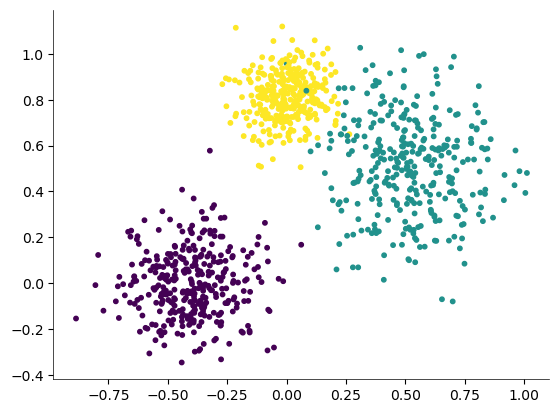

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import imageio

import matplotlib.pyplot as plt
import matplotlib as mpl
# make the axis lines thinner
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# supress all warnings and messages from matplotlib
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
random_state=42
run_name = 'paper_figure'
import os
folder_name = f'./exports/em/{run_name}'
os.makedirs(folder_name, exist_ok=True)

rng = np.random.RandomState(random_state)
# Generate synthetic dataset
n_samples = 1000
n_clusters = 3
n_features = 2

cluster_std = rng.rand(n_clusters, n_features)
X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features, random_state=random_state, cluster_std=cluster_std, center_box=(-2, 2))
# Specify the means and standard deviations for the clusters
x_means = [-0.4, 0.5, 0.]
y_means = [-0., 0.5, 0.8]
x_stds = [0.15, 0.2, 0.1]
y_stds = [0.15, 0.2, 0.1]

# Generate synthetic dataset with specified means and standard deviations
X, y = make_blobs(n_samples=n_samples, centers=np.column_stack((x_means, y_means)), 
                  cluster_std=np.column_stack((x_stds, y_stds)), random_state=random_state)
# plot the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=10)


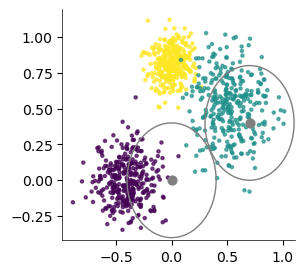

In [2]:

# plot the data
fig,ax = plt.subplots(1,1,figsize=(3, 3))
ax.scatter(X[:, 0], X[:, 1], c=y, s=5, alpha = 0.7)
# Define the coordinates for the circles
xc1, yc1 = 0, 0
xc2, yc2 = 0.7, 0.4
rc1, rc2 = .4, .4 

# First circle
ax.scatter(xc1, yc1, c='grey', s=40, alpha=1)
circle1 = plt.Circle((xc1, yc1), rc1, color='grey', fill=False, linewidth=1)
ax.add_artist(circle1)

# Second circle
ax.scatter(xc2, yc2, c='tab:grey', s=40, alpha=1)
circle2 = plt.Circle((xc2, yc2), rc2, color='tab:grey', fill=False, linewidth=1)
ax.add_artist(circle2)

Text(0, 0.5, 'Feature 2')

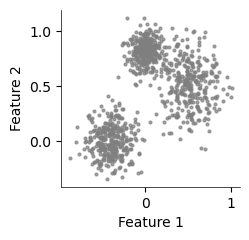

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 2.3))
ax.scatter(X[:, 0], X[:, 1], c='tab:grey', s=4, alpha=0.7)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')




In [4]:
def em_iteration(X, means, variances, responsibilities):
    n_clusters, n_features = means.shape
    n_samples = X.shape[0]
    
    # E-step: Update responsibilities
    distances = np.zeros((n_samples, n_clusters))
    for i in range(n_clusters):
        diff = X - means[i]
        inv_var = 1 / variances[i]
        exponent = -0.5 * np.sum(diff**2 * inv_var, axis=1)
        coef = (2 * np.pi * variances[i])**(-n_features/2)
        exponent = exponent.reshape(1000, 1)
        responsibilities[:, i] = (coef * np.exp(exponent))[:,0]
    
    responsibilities /= np.sum(responsibilities, axis=1, keepdims=True)
    
    # M-step: Update means and variances
    for i in range(n_clusters):
        weighted_sum = np.sum(responsibilities[:, i].reshape(-1, 1) * X, axis=0)
        total_weight = np.sum(responsibilities[:, i])
        means[i] = weighted_sum / total_weight
        
        diff = X - means[i]
        variances[i] = np.sum(responsibilities[:, i].reshape(-1, 1) * diff**2, axis=0) / total_weight
    
    # Assign labels
    labels = np.argmax(responsibilities, axis=1)
    
    return means, variances, labels

seed = 33 
rng = np.random.RandomState(seed)
n_iterations = 30
# n_clusters = 4
n_samples, n_features = X.shape
means = rng.rand(n_clusters, n_features)*2
variances = rng.rand(n_clusters, n_features)
responsibilities = np.zeros((n_samples, n_clusters))
# init random labels
labels = rng.randint(n_clusters, size=n_samples)


In [5]:

frames_data = []
frames_data.append((means.copy(), variances.copy(), labels.copy()))
frames = []
for i in range(n_iterations):
    means, variances, labels = em_iteration(X, means, variances, responsibilities)
    frames_data.append((means.copy(), variances.copy(), labels.copy()))



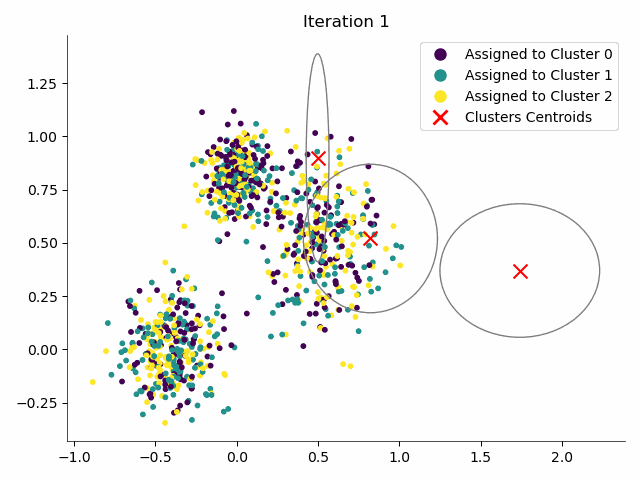

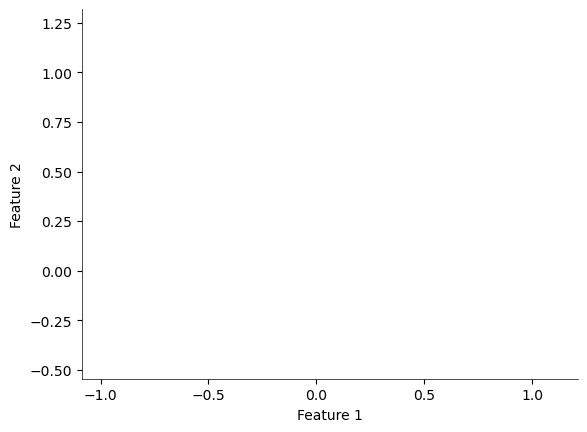

In [6]:
xlim = (X[:, 0].min() - .2, X[:, 0].max() + .2)
ylim = (X[:, 1].min() - .2, X[:, 1].max() + .2)

# means, variances, labels = frames_data[0]
frames = []
for i, (means, variances, labels) in enumerate(frames_data):
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
    plt.scatter(means[:, 0], means[:, 1], c='red', s=100, marker='x')
    # plot a light polygon around the centroid to indicate the 2D variance of the centroid
    for ci in range(n_clusters):
        var_scale = .5
        plt.gca().add_patch(mpl.patches.Ellipse(means[ci], variances[ci][0]**var_scale, variances[ci][1]**var_scale, color='tab:grey', fill=False))
    
    plt.title(f'Iteration {i+1}')
    plt.tight_layout()
    # Create a legend
    legend_elements = []
    for ci in range(n_clusters):
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Assigned to Cluster {ci}', markerfacecolor= plt.cm.viridis(ci/(n_clusters-1)) , markersize=10))
    # add an entry indicating that the centroids are marked with an 'x'
    legend_elements.append(plt.Line2D([0], [0], marker='x', color='w', label='Clusters Centroids', markerfacecolor='red', markersize=10, markeredgewidth=2, markeredgecolor='red'))
    plt.legend(handles=legend_elements)
    plt.savefig(f'./exports/em/frame_{i}.png')
    plt.close()
    frames.append(imageio.v2.imread(f'./exports/em/frame_{i}.png'))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

imageio.mimsave(f'{folder_name}/em_seed_{seed}.gif', frames, duration=0.2)

from IPython.display import Image

# Specify the path to the GIF file
gif_path = f'{folder_name}/em_seed_{seed}.gif'

# Display the GIF
Image(filename=gif_path)


In [7]:
# Initialize variables
rng = np.random.RandomState(2)  # fail 40  34 works
n_iterations = 30
n_samples, n_features = X.shape
means = rng.rand(n_clusters, n_features)
variances = rng.rand(n_clusters, n_features) / 100  # Lower the initial variances by 4
variances += np.ones_like(variances) * 0.01
responsibilities = np.zeros((n_samples, n_clusters))
labels = rng.randint(n_clusters, size=n_samples)

# Collect data instead of saving images
frames_data = {'E-step': [], 'M-step': []}
for i in range(8):
    means_new, variances_new, labels_new = em_iteration(X, np.copy(means), np.copy(variances), np.copy(responsibilities))
    labels = labels_new
    frames_data['E-step'].append((i+1, means.copy(), variances.copy(), labels.copy()))
    means, variances = means_new, variances_new
    frames_data['M-step'].append((i+1, means.copy(), variances.copy(), labels.copy()))

# Function to plot a single subplot
def plot_subplot(ax, step_type, iteration, means, variances, labels):
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=4, alpha=0.6, rasterized=True)
    ax.scatter(means[:, 0], means[:, 1], c='red', s=70, marker='x',alpha=1, )# alpha=0.5 if step_type == 'E-step' else 1)
    ax.set_title(f'Iteration {iteration}\n{step_type}')
    for ci in range(n_clusters):
        var_scale = 0.15
        ax.add_patch(mpl.patches.Ellipse(means[ci], variances[ci][0]**0.2, variances[ci][1]**var_scale, color='tab:grey', fill=False))
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

def plot_initial_subplot(ax):
    ax.scatter(X[:, 0], X[:, 1], c='tab:grey', s=4, alpha=0.6, rasterized=True)
    # ax.set_title('Initial Data')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')



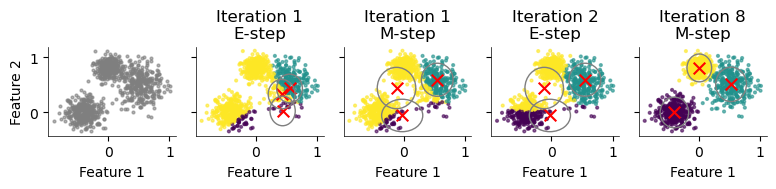

In [8]:

# Create figure with 4 subplots
# fig, axs = plt.subplots(2, 2, figsize=(4, 4), sharex=True, sharey=True)
fig, axs = plt.subplots(1, 5, figsize=(8, 2), sharex=True, sharey=True)

# Plot the subplots
# plot_subplot(axs[0, 0], 'E-step', *frames_data['E-step'][0])
# plot_subplot(axs[0, 1], 'M-step', *frames_data['M-step'][0])
# plot_subplot(axs[1, 0], 'E-step', *frames_data['E-step'][1])
# plot_subplot(axs[1, 1], 'M-step', *frames_data['M-step'][7])

plot_initial_subplot(axs.flat[0], )
plot_subplot(axs.flat[1], 'E-step', *frames_data['E-step'][0])
plot_subplot(axs.flat[2], 'M-step', *frames_data['M-step'][0])
# plot_subplot(axs.flat[3], 'M-step', *frames_data['M-step'][1])
plot_subplot(axs.flat[3], 'E-step', *frames_data['E-step'][1])
plot_subplot(axs.flat[4], 'M-step', *frames_data['M-step'][7])

for ax in axs.flat:
    ax.label_outer()
plt.tight_layout()
plt.savefig(f'{folder_name}/em_illustration.pdf', transparent=True)
